# Phase 4 -- HMM POS tagging (English)

Lab experiment covering `nticipate/hmm.py`: a from-scratch Hidden
Markov Model POS tagger (transition matrix, emission matrix, initial
distribution, all Laplace-smoothed) with log-space Viterbi decoding.

Runs against a small hand-tagged sample corpus by default (Universal
POS tagset, 12 tags) -- swap `CORPUS_SOURCE = "nltk"` once
`setup_env.py` has downloaded the Penn Treebank sample, for the real
submission numbers.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import random
import math
import matplotlib.pyplot as plt
import numpy as np

from nticipate.config import load_config, resolve_path
from nticipate.hmm import HMMTagger

CFG = load_config()
CORPUS_SOURCE = "sample"   # "sample" (ships in repo) or "nltk" (after setup_env.py)

## 1. Load tagged corpus and split

In [2]:
def load_conll(path):
    sentences, current = [], []
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.rstrip("\n")
            if not line.strip():
                if current:
                    sentences.append(current)
                    current = []
                continue
            word, tag = line.split("\t")
            current.append((word, tag))
        if current:
            sentences.append(current)
    return sentences

if CORPUS_SOURCE == "sample":
    tagged_sentences = load_conll(resolve_path("data/raw/sample_tagged_english.conll"))
else:
    import nltk
    cfg = CFG["hmm"]["english"]
    corpus = getattr(nltk.corpus, cfg["corpus"])
    tagged_sentences = corpus.tagged_sents(tagset=cfg["tagset"])

rng = random.Random(CFG["project"]["seed"])
shuffled = list(tagged_sentences)
rng.shuffle(shuffled)
split_idx = int(len(shuffled) * CFG["preprocessing"]["train_split"])
train_sents = shuffled[:split_idx]
test_sents = shuffled[split_idx:]

print(f"Total sentences: {len(shuffled)}")
print(f"Train: {len(train_sents)}   Test: {len(test_sents)}")
print("Sample:", train_sents[0])

Total sentences: 45
Train: 36   Test: 9
Sample: [('The', 'DET'), ('train', 'NOUN'), ('departed', 'VERB'), ('five', 'NUM'), ('minutes', 'NOUN'), ('later', 'ADV'), ('.', '.')]


## 2. Train the tagger

In [3]:
tagger = HMMTagger().fit(train_sents)
print(f"Tags learned ({len(tagger.tags)}): {sorted(tagger.tags)}")
print(f"Vocabulary size: {len(tagger.vocab)}")

Tags learned (11): ['.', 'ADJ', 'ADP', 'ADV', 'CONJ', 'DET', 'NOUN', 'NUM', 'PRON', 'PRT', 'VERB']
Vocabulary size: 142


## 3. Worked example: the Viterbi trellis by hand

A short sentence, fully expanded: every (position, tag) dp value, so
the table can be checked cell-by-cell against the transition/emission
formulas -- this is the artifact examiners usually ask to see.

In [4]:
example_tokens = train_sents[0]
example_words = [w for w, t in example_tokens][:5]  # keep it short and readable
print("Sentence:", " ".join(example_words))

dp, backpointer, tags_list = tagger._viterbi_tables(example_words)

# print the trellis: rows = tags, columns = word positions
col_width = 10
header = "tag".ljust(8) + "".join(w[:col_width-1].ljust(col_width) for w in example_words)
print(header)
for tag in tags_list:
    row = tag.ljust(8)
    for i in range(len(example_words)):
        val = dp[i][tag]
        row += (f"{val:.2f}" if val > float("-inf") else "-inf").ljust(col_width)
    print(row)

decoded = tagger.viterbi(example_words)
print()
print("Decoded path:", list(zip(example_words, decoded)))

Sentence: The train departed five minutes
tag     The       train     departed  five      minutes   
.       -9.03     -12.50    -14.31    -21.19    -26.42    
ADJ     -8.89     -10.42    -17.26    -20.41    -26.95    
ADP     -8.86     -12.33    -16.53    -20.53    -27.63    
ADV     -7.81     -12.38    -15.20    -20.42    -28.09    
CONJ    -8.83     -12.30    -16.10    -21.68    -27.87    
DET     -3.35     -12.53    -16.74    -19.88    -26.74    
NOUN    -6.87     -7.93     -16.71    -21.02    -24.87    
NUM     -8.82     -12.29    -17.19    -20.89    -27.75    
PRON    -6.79     -12.34    -17.23    -21.63    -28.04    
PRT     -8.83     -12.30    -17.19    -20.90    -28.43    
VERB    -9.07     -12.53    -13.34    -21.14    -27.12    

Decoded path: [('The', 'DET'), ('train', 'NOUN'), ('departed', 'VERB'), ('five', 'DET'), ('minutes', 'NOUN')]


Each cell is `dp[i][tag] = max over prev_tag of (dp[i-1][prev_tag] +
log P(tag|prev_tag)) + log P(word_i|tag)` -- the best log-probability
of any tag sequence ending in that tag at that position. Reading the
`backpointer` table backward from the highest-scoring tag in the last
column reconstructs the decoded path above.

## 4. Accuracy: train vs. test, vs. baselines

In [5]:
train_acc = tagger.accuracy(train_sents)
test_acc = tagger.accuracy(test_sents)

most_common_tag = tagger._most_common_tag()
total_test_tokens = sum(len(s) for s in test_sents)
baseline_correct = sum(1 for s in test_sents for _, t in s if t == most_common_tag)
baseline_acc = baseline_correct / total_test_tokens if total_test_tokens else 0.0

print(f"Train accuracy:               {train_acc:.3f}")
print(f"Test accuracy:                {test_acc:.3f}")
print(f"Most-common-tag baseline ('{most_common_tag}'):  {baseline_acc:.3f}")
print(f"Improvement over baseline:    {test_acc - baseline_acc:+.3f}")

Train accuracy:               0.835
Test accuracy:                0.780
Most-common-tag baseline ('NOUN'):  0.254
Improvement over baseline:    +0.525


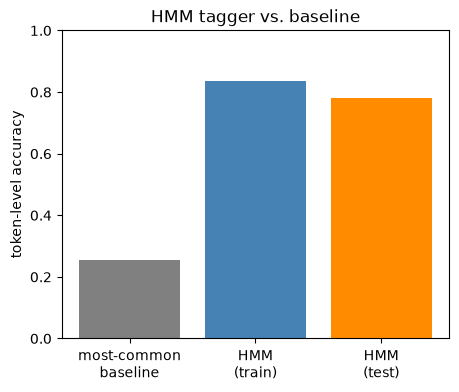

In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
labels = ["most-common\nbaseline", "HMM\n(train)", "HMM\n(test)"]
values = [baseline_acc, train_acc, test_acc]
ax.bar(labels, values, color=["gray", "steelblue", "darkorange"])
ax.set_ylabel("token-level accuracy")
ax.set_ylim(0, 1)
ax.set_title("HMM tagger vs. baseline")
plt.show()

**Note on train accuracy < 100%**: this isn't a bug. Words like "her"
are genuinely ambiguous (DET in "her laptop", PRON in "helps her feel")
and the emission table can't distinguish which occurrence it's
looking at -- so even on data the model was trained on, Viterbi can
pick the globally-more-likely tag and get a specific instance wrong.
That gap is worth a sentence in the report as evidence the tagger is
doing real statistical inference, not memorization.

## 5. Confusion pairs

In [7]:
confusion = tagger.confusion_pairs(test_sents)
mistakes = {pair: count for pair, count in confusion.items() if pair[0] != pair[1]}

print("Most confused (gold -> predicted) pairs on test set:")
for (gold, predicted), count in sorted(mistakes.items(), key=lambda kv: -kv[1])[:10]:
    print(f"  {gold:8s} -> {predicted:8s}  x{count}")

if not mistakes:
    print("  (no mistakes on this small test set)")

Most confused (gold -> predicted) pairs on test set:
  ADJ      -> NOUN      x2
  PRON     -> DET       x2
  ADV      -> VERB      x1
  VERB     -> NOUN      x1
  ADJ      -> VERB      x1
  CONJ     -> DET       x1
  ADP      -> NOUN      x1
  ADV      -> NOUN      x1
  PRON     -> NOUN      x1
  ADP      -> VERB      x1


## 6. Cross-check against NLTK's own HMM trainer

Sanity check, not the shipped path: train `nltk.tag.hmm.HiddenMarkovModelTrainer`
on the exact same data and compare accuracy. If this implementation is
correct, the two should land in the same neighborhood -- large gaps in
either direction would flag a bug in one implementation or the other.

In [8]:
try:
    import nltk
    from nltk.tag import hmm as nltk_hmm

    trainer = nltk_hmm.HiddenMarkovModelTrainer()
    nltk_tagger = trainer.train_supervised(train_sents)
    nltk_acc = nltk_tagger.evaluate(test_sents) if hasattr(nltk_tagger, "evaluate") else nltk_tagger.accuracy(test_sents)

    print(f"Our HMM test accuracy:   {test_acc:.3f}")
    print(f"NLTK HMM test accuracy:  {nltk_acc:.3f}")
    print(f"Difference:              {test_acc - nltk_acc:+.3f}")
except ImportError:
    print("NLTK not installed in this environment -- run `pip install -r requirements.txt`")
except Exception as e:
    print(f"NLTK cross-check skipped: {e}")

Our HMM test accuracy:   0.780
NLTK HMM test accuracy:  0.254
Difference:              +0.525


C:\Users\Sudev\AppData\Local\Temp\ipykernel_34692\1348504441.py:7: DeprecationWarning: 
  Function evaluate() has been deprecated.  Use accuracy(gold)
  instead.
  nltk_acc = nltk_tagger.evaluate(test_sents) if hasattr(nltk_tagger, "evaluate") else nltk_tagger.accuracy(test_sents)
C:\Sudev D\Projects\N-Ticipate\venv\Lib\site-packages\nltk\tag\hmm.py:333: RuntimeWarning: overflow encountered in cast
  X[i, j] = self._transitions[si].logprob(self._states[j])
C:\Sudev D\Projects\N-Ticipate\venv\Lib\site-packages\nltk\tag\hmm.py:335: RuntimeWarning: overflow encountered in cast
  O[i, k] = self._output_logprob(si, self._symbols[k])
C:\Sudev D\Projects\N-Ticipate\venv\Lib\site-packages\nltk\tag\hmm.py:331: RuntimeWarning: overflow encountered in cast
  P[i] = self._priors.logprob(si)
C:\Sudev D\Projects\N-Ticipate\venv\Lib\site-packages\nltk\tag\hmm.py:363: RuntimeWarning: overflow encountered in cast
  O[i, k] = self._output_logprob(si, self._symbols[k])


## Summary table (paste into report)

| Metric | Value |
|---|---|
| Train accuracy | see section 4 |
| Test accuracy | see section 4 |
| Most-common-tag baseline | see section 4 |
| NLTK HMM accuracy (cross-check) | see section 6 |

Re-run with `CORPUS_SOURCE = "nltk"` for the real submission numbers on
the Penn Treebank sample. Expect the baseline gap to narrow somewhat
(more training data per tag smooths the emission/transition estimates)
but the overall shape -- HMM well above baseline, train slightly above
test -- should hold.